# **Assignment 4 - Tree and Graph Visualization**

**Student ID:** A4_2023xxx

---

## **Datasets Used**

### **1. Tree Visualization Dataset**
- **Dataset:** Drug Classification (drug200.csv)
- **Source:** Kaggle - pablomgomez21
- **Description:** 200 patient records with Age, Sex, Blood Pressure, Cholesterol, and Na-to-K ratio. Goal is to predict which drug (A, B, C, X, Y) to prescribe.
- **Nodes:** Decision rules (e.g. Na_to_K <= 14.8) or final drug predictions at the leaves.
- **Edges:** Yes/No branches connecting each decision to the next step.

### **2. Graph Visualization Dataset**
- **Dataset:** Daily Internet Usage (daily_internet_usage_by_age_group.csv)
- **Source:** Kaggle - jayjoshi2121
- **Description:** Daily screen time data across different age groups and devices.
- **Nodes:** Age groups (13-18, 19-25, etc.) and devices (Mobile, Laptop, etc.).
- **Edges:** Connection between an age group and a device, weighted by average daily screen time.

In [1]:
# Importing the libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from sklearn.tree import DecisionTreeClassifier, export_text, _tree
from sklearn.preprocessing import LabelEncoder

print("Libraries loaded successfully")

Libraries loaded successfully


---
## **Part 1 - Tree Visualization**
**Dataset: Drug Classification (drug200.csv)**

In [3]:
# Load the drug dataset
df = pd.read_csv("drug200.csv")

print("Shape:", df.shape)
print("First few rows:")
df.head()

Shape: (200, 6)
First few rows:


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [5]:
# The dataset has text columns like Sex, BP, Cholesterol
# We need to convert them to numbers before training
data = df.copy()

le = LabelEncoder()
data["Sex"]         = le.fit_transform(data["Sex"])
data["BP"]          = le.fit_transform(data["BP"])
data["Cholesterol"] = le.fit_transform(data["Cholesterol"])
data["Drug"]        = le.fit_transform(data["Drug"])

# Store original drug names before encoding
drug_names = sorted(df["Drug"].unique())

features = ["Age", "Sex", "BP", "Cholesterol", "Na_to_K"]
X = data[features].values
y = data["Drug"].values

# Train a decision tree - keeping depth at 4 so the tree stays readable
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X, y)

accuracy = (tree_model.predict(X) == y).mean() * 100
print(f"Model trained! Accuracy: {accuracy:.1f}%")
print("Tree structure:")
print(export_text(tree_model, feature_names=features, max_depth=3))

Model trained! Accuracy: 100.0%
Tree structure:
|--- Na_to_K <= 14.83
|   |--- BP <= 0.50
|   |   |--- Age <= 50.50
|   |   |   |--- class: 0
|   |   |--- Age >  50.50
|   |   |   |--- class: 1
|   |--- BP >  0.50
|   |   |--- BP <= 1.50
|   |   |   |--- Cholesterol <= 0.50
|   |   |   |   |--- class: 2
|   |   |   |--- Cholesterol >  0.50
|   |   |   |   |--- class: 3
|   |   |--- BP >  1.50
|   |   |   |--- class: 3
|--- Na_to_K >  14.83
|   |--- class: 4



In [8]:
# Color each drug with a distinct color
drug_colors = {
    "drugA": "#FF6B6B",
    "drugB": "#4ECDC4",
    "drugC": "#45B7D1",
    "drugX": "#96CEB4",
    "drugY": "#FFEAA7"
}

# This function walks through the trained tree and builds a NetworkX graph
def tree_to_graph(model, feature_names, drug_names):
    t = model.tree_
    G = nx.DiGraph()
    node_labels = {}
    node_colors = {}

    def walk(node):
        if t.feature[node] != _tree.TREE_UNDEFINED:
            # This is a decision node
            feat  = feature_names[t.feature[node]]
            thr   = t.threshold[node]
            label = f"{feat}<= {thr:.2f}"
            color = "#B8C6DB"
        else:
            # This is a leaf node
            drug  = drug_names[np.argmax(t.value[node])]
            count = int(t.n_node_samples[node])
            label = f"{drug}(n={count})"
            color = drug_colors.get(drug, "#DDA0DD")

        G.add_node(node)
        node_labels[node] = label
        node_colors[node] = color

        left  = t.children_left[node]
        right = t.children_right[node]
        if left != _tree.TREE_LEAF:
            G.add_edge(node, left,  label="Yes")
            G.add_edge(node, right, label="No")
            walk(left)
            walk(right)

    walk(0)
    return G, node_labels, node_colors


G, node_labels, node_colors = tree_to_graph(tree_model, features, drug_names)
edge_labels = nx.get_edge_attributes(G, "label")
color_list  = [node_colors[n] for n in G.nodes()]

# Build the legend
legend = [mpatches.Patch(color=c, label=d) for d, c in drug_colors.items()]
legend.append(mpatches.Patch(color="#B8C6DB", label="Decision Node"))

print(f"Tree graph built: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Tree graph built: 11 nodes, 10 edges


### **Tree Layout 1 - Top-Down**
Root node is at the top and branches go downward. Each node shows the decision rule and leaf nodes are colored by the predicted drug.

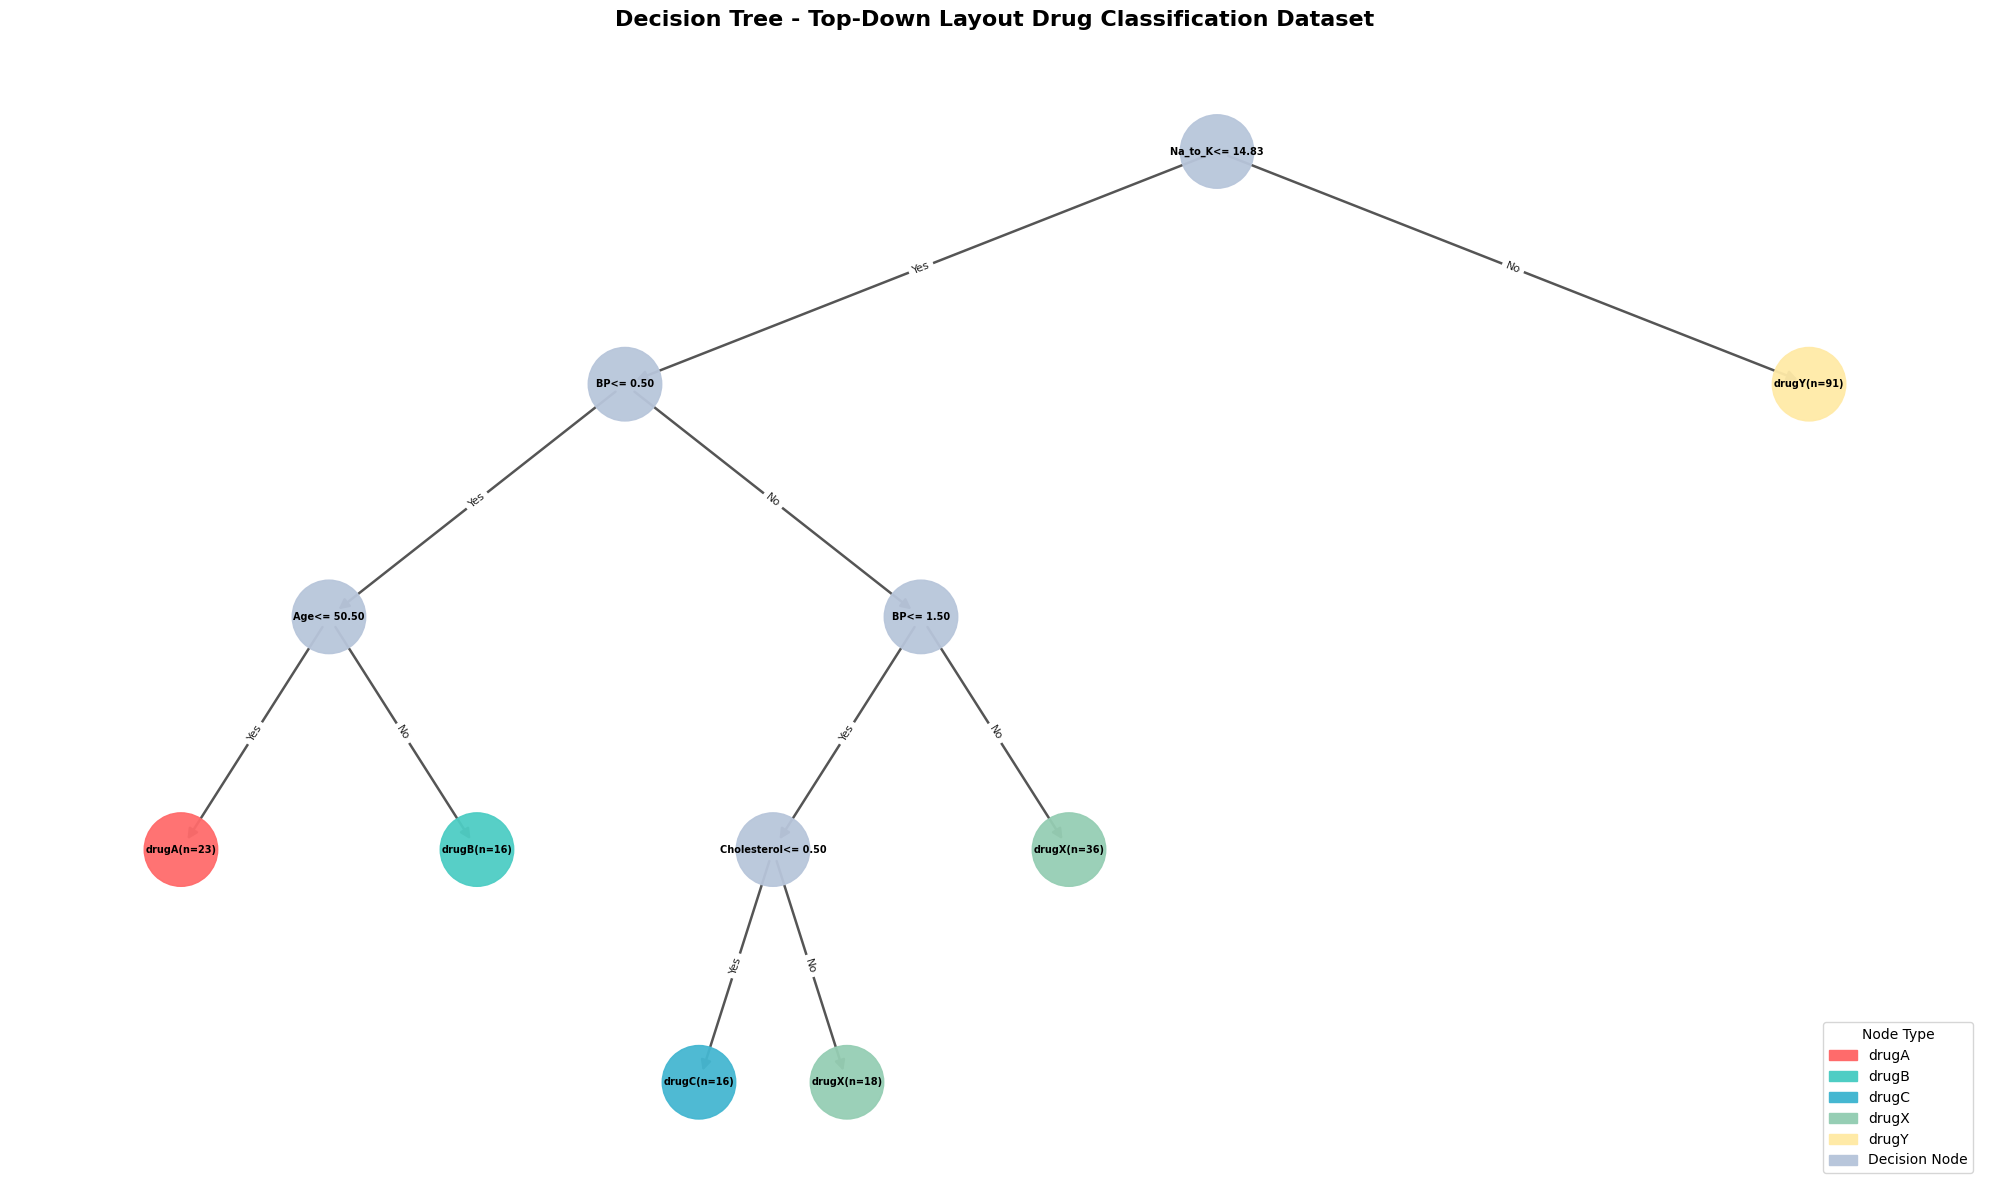

In [10]:
# Position nodes top to bottom
def top_down_pos(G, root=0, width=2.0, gap=0.18):
    pos = {}
    def place(node, left, right, y):
        pos[node] = ((left + right) / 2, y)
        children = list(G.successors(node))
        if children:
            step = (right - left) / len(children)
            for i, child in enumerate(children):
                place(child, left + i*step, left + (i+1)*step, y - gap)
    place(root, 0, width, 0)
    return pos


pos1 = top_down_pos(G)

fig, ax = plt.subplots(figsize=(20, 12))
ax.set_title("Decision Tree - Top-Down Layout Drug Classification Dataset", fontsize=16, fontweight="bold", pad=20)

nx.draw_networkx_nodes(G, pos1, node_color=color_list, node_size=2800, ax=ax, alpha=0.95)
nx.draw_networkx_labels(G, pos1, node_labels, font_size=7, font_weight="bold", ax=ax)
nx.draw_networkx_edges(G, pos1, edge_color="#555", arrows=True, arrowsize=15, width=1.8, ax=ax)
nx.draw_networkx_edge_labels(G, pos1, edge_labels, font_size=8, font_color="#222", ax=ax)

ax.legend(handles=legend, loc="lower right", fontsize=10, title="Node Type")
ax.axis("off")
plt.tight_layout()
plt.savefig("tree_layout1_topdown.png", dpi=150, bbox_inches="tight")
plt.show()

### **Tree Layout 2 - Left to Right**
Same tree drawn horizontally. Root is on the left and leaves are on the right. Easy to trace a decision path from start to finish.

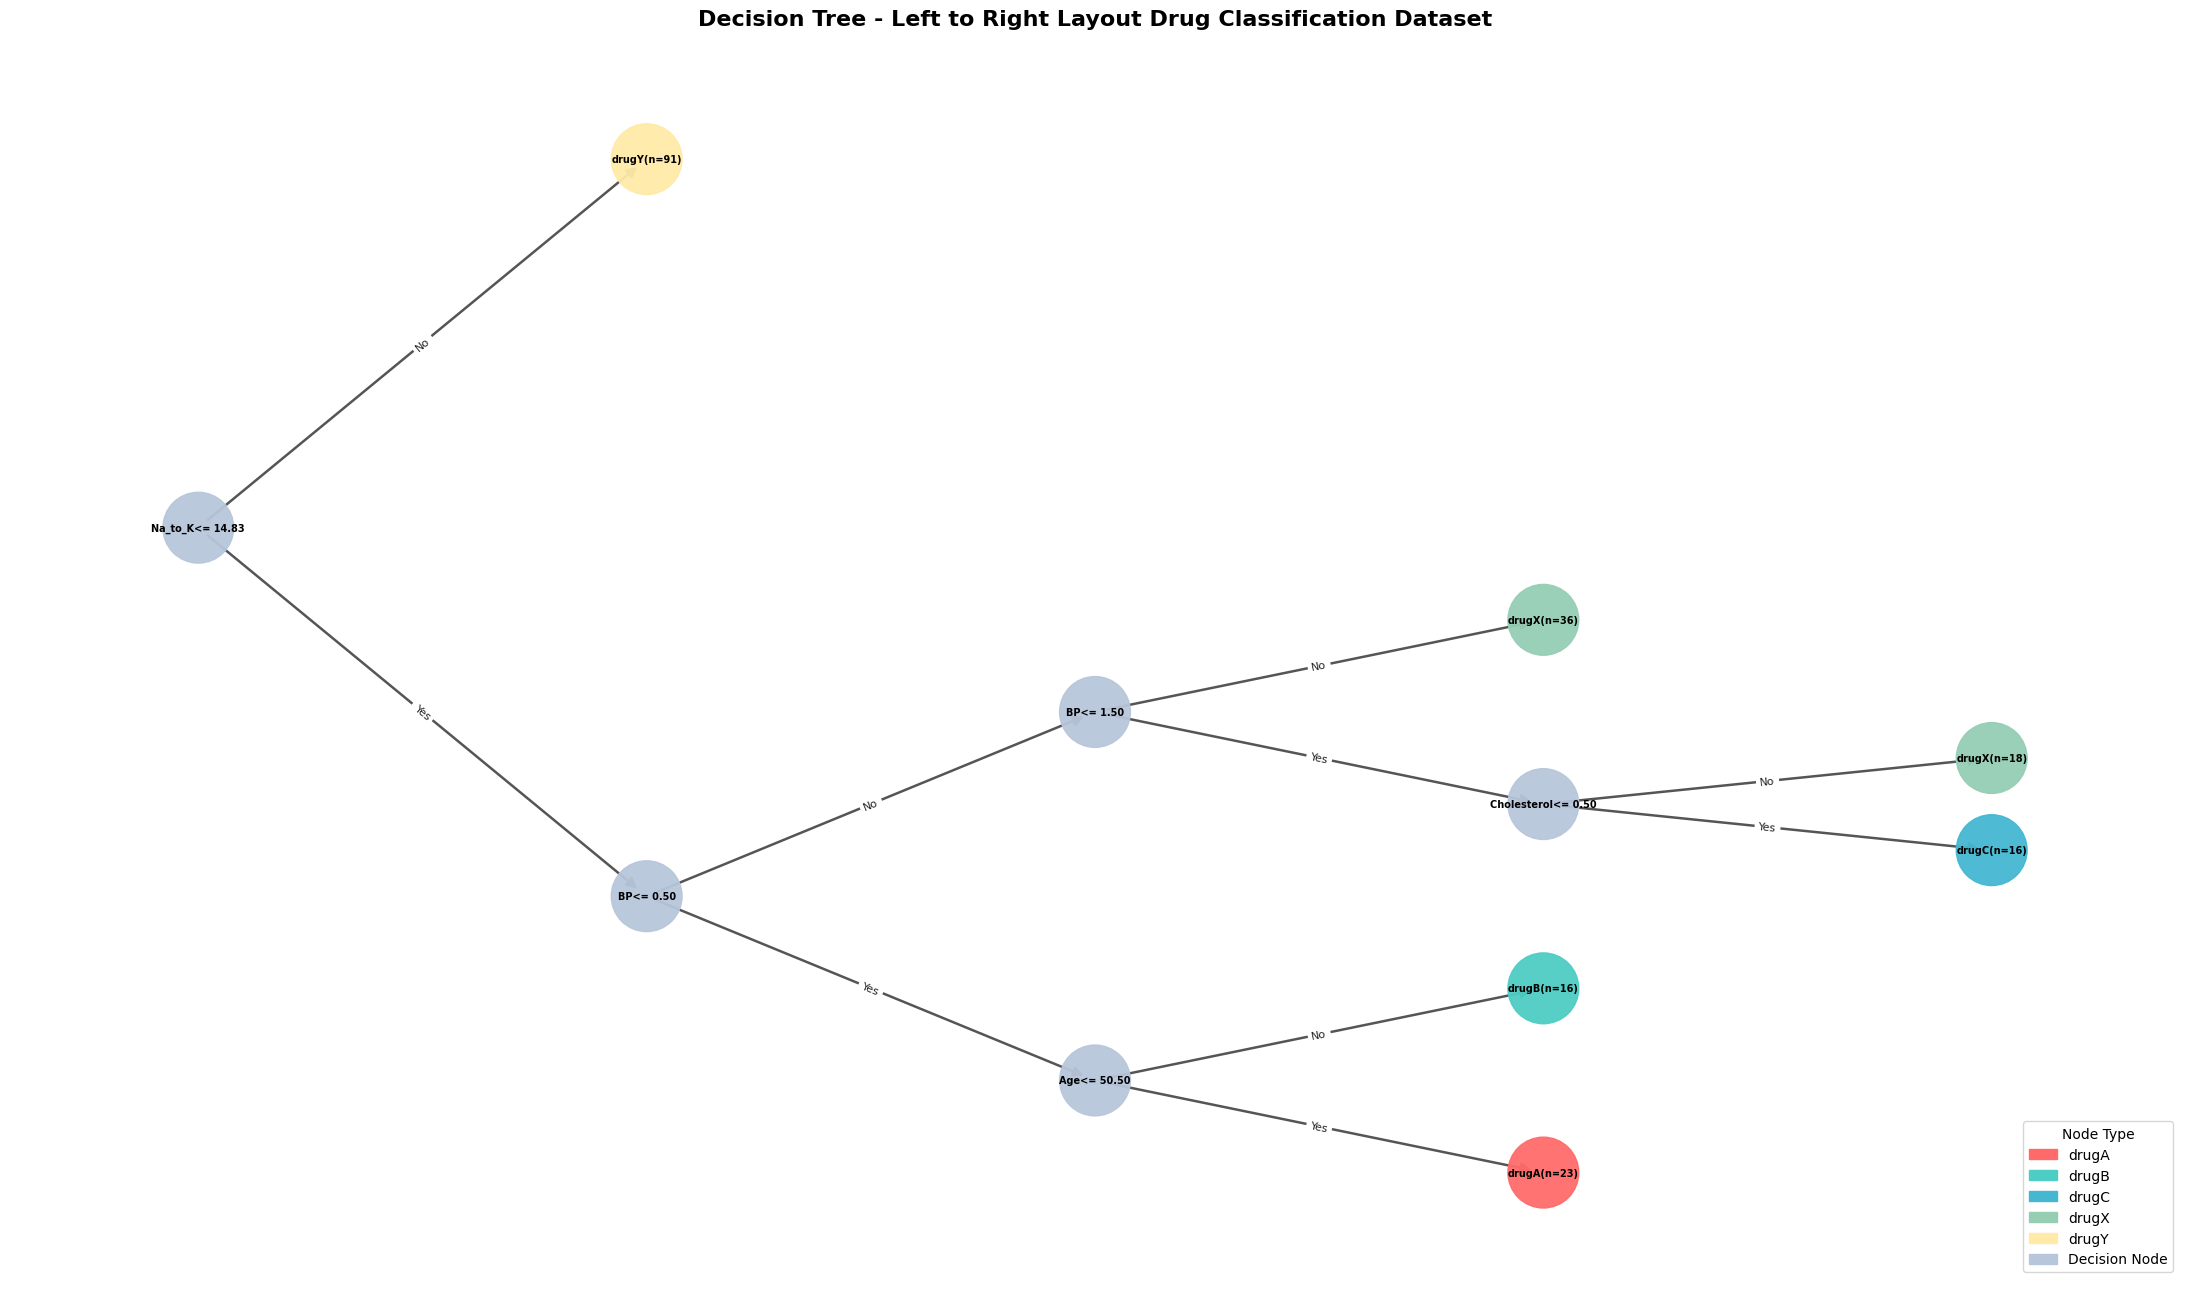

In [11]:
# Position nodes left to right
def left_right_pos(G, root=0, height=2.0, gap=0.32):
    pos = {}
    def place(node, top, bottom, x):
        pos[node] = (x, (top + bottom) / 2)
        children = list(G.successors(node))
        if children:
            step = (bottom - top) / len(children)
            for i, child in enumerate(children):
                place(child, top + i*step, top + (i+1)*step, x + gap)
    place(root, 0, height, 0)
    return pos


pos2 = left_right_pos(G)

fig, ax = plt.subplots(figsize=(22, 13))
ax.set_title("Decision Tree - Left to Right Layout Drug Classification Dataset",fontsize=16, fontweight="bold", pad=20)

nx.draw_networkx_nodes(G, pos2, node_color=color_list, node_size=2600, ax=ax, alpha=0.95)
nx.draw_networkx_labels(G, pos2, node_labels, font_size=7, font_weight="bold", ax=ax)
nx.draw_networkx_edges(G, pos2, edge_color="#555", arrows=True, arrowsize=15, width=1.8, ax=ax)
nx.draw_networkx_edge_labels(G, pos2, edge_labels, font_size=8, font_color="#222", ax=ax)

ax.legend(handles=legend, loc="lower right", fontsize=10, title="Node Type")
ax.axis("off")
plt.tight_layout()
plt.savefig("tree_layout2_lr.png", dpi=150, bbox_inches="tight")
plt.show()

---
## **Part 2 - Graph Visualization**
**Dataset: Daily Internet Usage (daily_internet_usage_by_age_group.csv)**

In [12]:
# Load the internet usage dataset
usage = pd.read_csv("daily_internet_usage_by_age_group.csv")

print("Shape:", usage.shape)
print("Columns:", usage.columns.tolist())
print("Age groups:", usage["age_group"].unique())
print("Devices:",    usage["primary_device"].unique())
usage.head()

Shape: (2800, 10)
Columns: ['user_id', 'date', 'age', 'age_group', 'social_media_hours', 'work_or_study_hours', 'entertainment_hours', 'total_screen_time', 'primary_device', 'internet_type']
Age groups: ['13-18' '19-25' '26-35' '46-60' '36-45' '60+']
Devices: ['Mobile' 'Tablet' 'Laptop']


,user_id,date,age,age_group,social_media_hours,work_or_study_hours,entertainment_hours,total_screen_time,primary_device,internet_type
0,1,2024-04-02,15,13-18,2.2,3.7,2.4,8.3,Mobile,WiFi
1,2,2024-06-07,13,13-18,1.1,6.9,2.1,10.1,Tablet,WiFi
2,3,2024-04-03,21,19-25,1.3,5.7,1.6,8.6,Tablet,WiFi
3,4,2024-10-02,35,26-35,2.5,5.0,2.0,9.5,Mobile,WiFi
4,5,2024-10-05,49,46-60,0.2,6.3,2.8,9.3,Laptop,WiFi


In [14]:
# For the graph, we connect each age group to the devices they use
# The edge weight is the average daily screen time for that combination

edge_data = usage.groupby(["age_group", "primary_device"])["total_screen_time"].mean().reset_index()
edge_data.columns = ["age_group", "device", "avg_hours"]

print("Connections (age group + device + avg screen hours):")
print(edge_data.to_string(index=False))

# Build the graph
BG = nx.Graph()

age_groups = edge_data["age_group"].unique().tolist()
devices    = edge_data["device"].unique().tolist()

BG.add_nodes_from(age_groups, type="age")
BG.add_nodes_from(devices,    type="device")

for _, row in edge_data.iterrows():
    BG.add_edge(row["age_group"], row["device"], weight=round(row["avg_hours"], 2))

print(f"Graph: {BG.number_of_nodes()} nodes, {BG.number_of_edges()} edges")

Connections (age group + device + avg screen hours):
age_group device  avg_hours
    13-18 Laptop   8.248993
    13-18 Mobile   8.125564
    13-18 Tablet   8.242771
    19-25 Laptop   7.791275
    19-25 Mobile   8.170492
    19-25 Tablet   8.032414
    26-35 Laptop   8.052023
    26-35 Mobile   8.273563
    26-35 Tablet   8.387671
    36-45 Laptop   8.302532
    36-45 Mobile   8.256589
    36-45 Tablet   8.601316
    46-60 Laptop   8.162838
    46-60 Mobile   7.961184
    46-60 Tablet   8.057055
      60+ Laptop   7.991946
      60+ Mobile   8.066234
      60+ Tablet   8.076836
Graph: 9 nodes, 18 edges


### **Graph Layout 1 - Bipartite Layout**
Age groups are on the left and devices are on the right. Line thickness shows how many hours per day that age group uses that device.

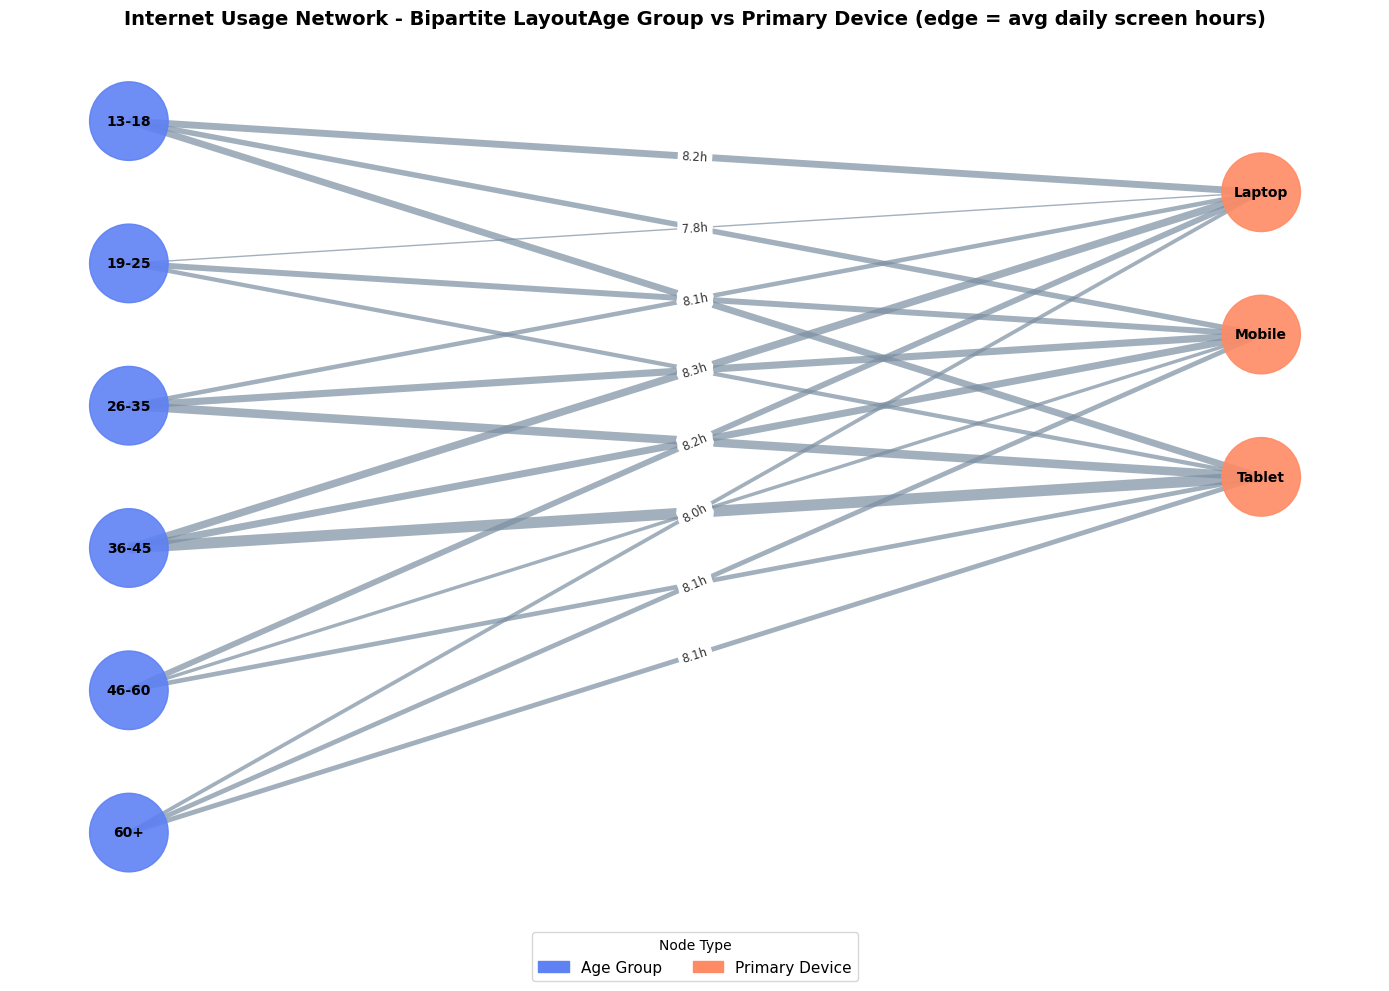

In [15]:
# Colors for nodes
age_color    = "#5E81F4"
device_color = "#FF8B64"

# Place age groups on the left, devices on the right
pos_bip = {}
for i, ag in enumerate(sorted(age_groups)):
    pos_bip[ag] = (0, -i * 1.5)
for j, dev in enumerate(sorted(devices)):
    pos_bip[dev] = (4, -j * 1.5 - 0.75)

# Scale edge widths based on avg hours
weights    = [BG[u][v]["weight"] for u, v in BG.edges()]
min_w, max_w = min(weights), max(weights)
widths     = [1 + 7 * (w - min_w) / (max_w - min_w + 0.001) for w in weights]
elabels    = {(u, v): f"{d['weight']:.1f}h" for u, v, d in BG.edges(data=True)}
node_colors_bg = [age_color if n in age_groups else device_color for n in BG.nodes()]

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_title("Internet Usage Network - Bipartite LayoutAge Group vs Primary Device (edge = avg daily screen hours)",fontsize=14, fontweight="bold", pad=16)

nx.draw_networkx_nodes(BG, pos_bip, node_color=node_colors_bg, node_size=3200, ax=ax, alpha=0.9)
nx.draw_networkx_labels(BG, pos_bip, font_size=10, font_weight="bold", ax=ax)
nx.draw_networkx_edges(BG, pos_bip, width=widths, edge_color="#7B8FA1", ax=ax, alpha=0.7)
nx.draw_networkx_edge_labels(BG, pos_bip, elabels, font_size=8.5, font_color="#333", ax=ax)

leg = [
    mpatches.Patch(color=age_color,    label="Age Group"),
    mpatches.Patch(color=device_color, label="Primary Device")
]
ax.legend(handles=leg, fontsize=11, loc="upper center",title="Node Type", bbox_to_anchor=(0.5, -0.02), ncol=2)
ax.axis("off")
plt.tight_layout()
plt.savefig("graph_layout1_bipartite.png", dpi=150, bbox_inches="tight")
plt.show()

### **Graph Layout 2 - Circular Layout**
All nodes are arranged in a circle. Age groups and devices alternate around the ring, and edges connect them based on usage. Edge thickness shows average screen time.

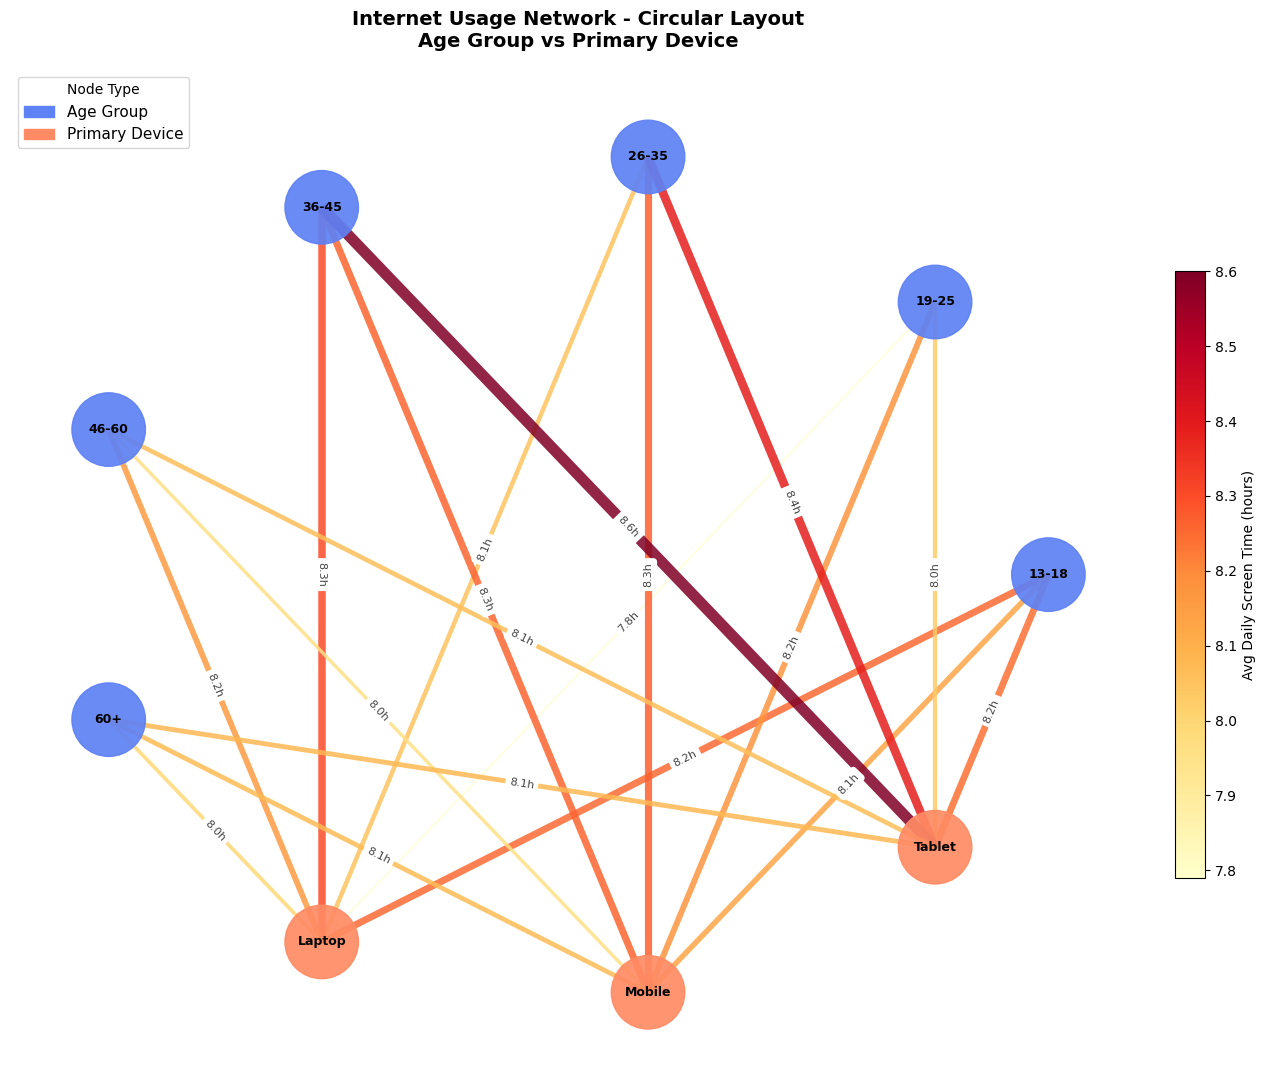

In [16]:
# Circular layout - nodes are evenly placed around a circle
pos_circ = nx.circular_layout(BG)

fig, ax = plt.subplots(figsize=(14, 11))
ax.set_title("Internet Usage Network - Circular Layout\nAge Group vs Primary Device",fontsize=14, fontweight="bold", pad=16)

nx.draw_networkx_edges(BG, pos_circ, width=widths,edge_color=weights, edge_cmap=plt.cm.YlOrRd,ax=ax, alpha=0.85)
nx.draw_networkx_nodes(BG, pos_circ, node_color=node_colors_bg,node_size=2800, ax=ax, alpha=0.92)
nx.draw_networkx_labels(BG, pos_circ, font_size=9, font_weight="bold", ax=ax)
nx.draw_networkx_edge_labels(BG, pos_circ, elabels, font_size=8, font_color="#444", ax=ax)

sm = plt.cm.ScalarMappable(cmap=plt.cm.YlOrRd,norm=plt.Normalize(vmin=min_w, vmax=max_w))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label("Avg Daily Screen Time (hours)", fontsize=10)

ax.legend(handles=leg, fontsize=11, loc="upper left", title="Node Type")
ax.axis("off")
plt.tight_layout()
plt.savefig("graph_layout2_circular.png", dpi=150, bbox_inches="tight")
plt.show()

---
## **Summary**

| | Dataset | Visualization | Layouts |
|---|---|---|---|
| **Tree** | drug200.csv | Decision Tree | Top-Down, Left to Right |
| **Graph** | daily_internet_usage_by_age_group.csv | Bipartite Network | Bipartite, Circular |

**Key Findings:**
- Na_to_K is the most important feature in the drug tree. Patients with Na_to_K above 14.8 almost always get drugY.
- Mobile is the most used device across all age groups, especially for users aged 13 to 25.
- The circular layout makes it easy to see which devices connect to multiple age groups.